In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv(r"../Datos/Accidentes de Transito - Dataset.csv")

In [2]:
meses = {'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
         'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}

df['Mes'] = df['Mes'].map(meses)
df.head()

,Mes,Año,Accidentes,Temperatura Prom. del Mes (°C),Acum. Lluvia Diaria,Días Hábiles del mes,Inicio de Clases,Precio Gasolina (95 Octanos),Accidentes del mes anterior,IMAE
0,1,2017,2683,27.15,0.00,22,0,0.77,3237,309.60
1,2,2017,2606,27.35,18.50,20,0,0.75,2683,312.23
2,3,2017,3033,28.55,6.35,23,1,0.73,2606,315.04
3,4,2017,2738,28.70,60.50,20,0,0.75,3033,317.64
4,5,2017,2972,27.85,228.95,23,0,0.75,2738,319.50


<Axes: >

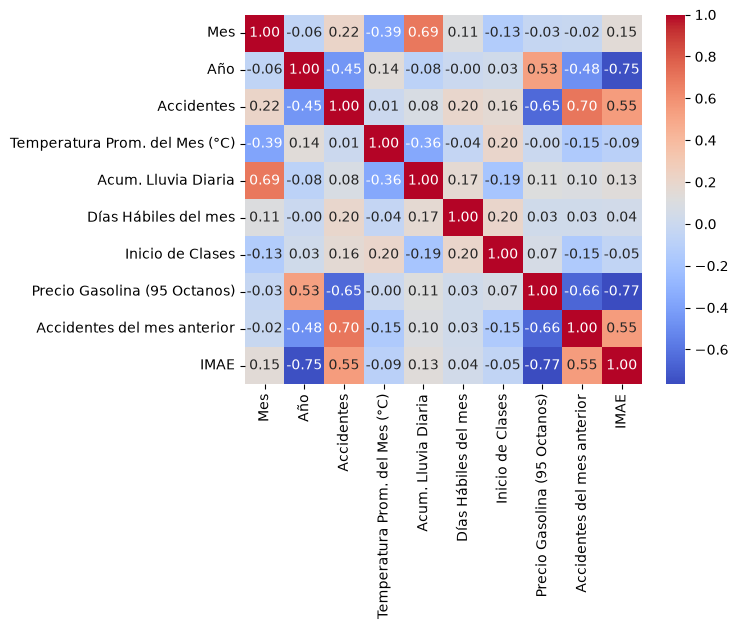

In [3]:
#Generar mapa de calor de correlaciones

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

La accidentalidad se explica principalmente por su propia inercia temporal (Accidentes del mes anterior, r=0.70) y por factores económicos: Precio Gasolina (r=-0.65) e IMAE (r=0.55), mientras que las variables climáticas (Temperatura y Lluvia) no muestran relación relevante con el target.

Un hallazgo adicional relevante es que estas mismas variables económicas están fuertemente correlacionadas entre sí (Precio Gasolina vs. IMAE, r=-0.77; Año vs. IMAE, r=-0.75), lo que sugiere que no aportan información completamente independiente y podrían generar multicolinealidad si se usan juntas en un modelo predictivo.

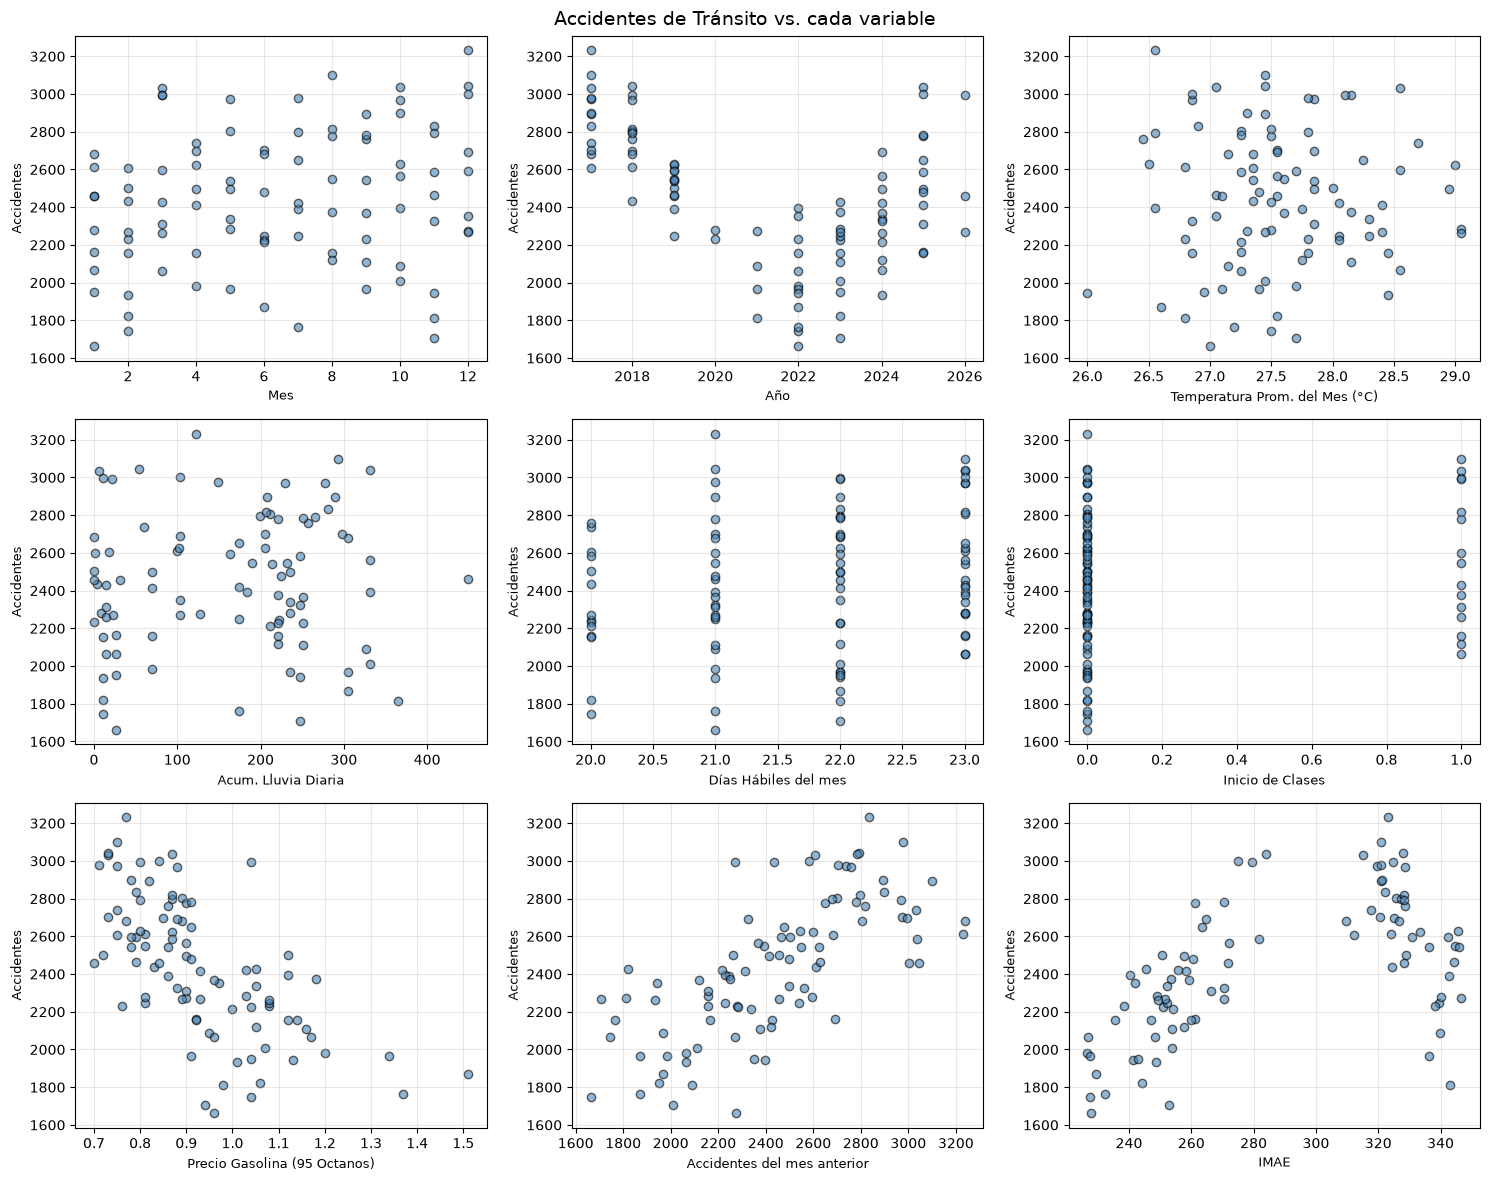

In [7]:
features = ['Mes', 'Año', 'Temperatura Prom. del Mes (°C)', 'Acum. Lluvia Diaria',
            'Días Hábiles del mes', 'Inicio de Clases', 'Precio Gasolina (95 Octanos)',
            'Accidentes del mes anterior', 'IMAE']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Accidentes'], alpha=0.6, color='steelblue', edgecolor='black')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Accidentes', fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('Accidentes de Tránsito vs. cada variable', fontsize=14)
plt.tight_layout()
plt.show()

Los diagramas de dispersión confirman visualmente los hallazgos de la matriz de correlación: Accidentes del mes anterior, Precio Gasolina e IMAE muestran relaciones claras con la variable objetivo, mientras que Temperatura y Lluvia no presentan ningún patrón.

In [5]:
features = features = ['Accidentes del mes anterior', 'Precio Gasolina (95 Octanos)', 'Año']

X = df[features]
y = df['Accidentes']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.51,-698.23, -3.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Accidentes del mes anterior','Precio Gasolina (95 Octanos)','Año']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9695
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import numpy as np

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=kf, scoring='r2')


print(f"MAE:  {mae:.0f} accidentes")
print(f"RMSE: {rmse:.0f} accidentes")
print(f"R² por fold: {scores}")
print(f"R² promedio (CV): {scores.mean():.3f} ± {scores.std():.3f}")

MAE:  171 accidentes
RMSE: 212 accidentes
R² por fold: [0.62937771 0.52275065 0.36107567 0.36452111 0.52244321]
R² promedio (CV): 0.480 ± 0.103


El modelo de regresión lineal, evaluado mediante validación cruzada (5 folds), explica en promedio un 48% de la variabilidad de Accidentes (R² = 0.480 ± 0.103), con un error absoluto promedio de 171 accidentes y un error cuadrático medio de 212 accidentes. Esto indica un desempeño moderado: el modelo captura una parte importante de la relación entre las variables predictoras y la accidentalidad, pero aún queda una porción considerable de la variabilidad sin explicar, probablemente asociada a factores no incluidos en el modelo o a la naturaleza no completamente lineal de algunas relaciones.